In [5]:
from google.colab import files
uploaded = files.upload()

Saving merged_dataset.csv to merged_dataset.csv


# Exploratory Data Analysis (EDA)

In this notebook, the merged dataset is explored using summary statistics and visualizations. The goal is to understand the distributions of the main variables, identify possible outliers, and observe preliminary relationships between inflation, obesity, and fast food availability across countries.

The analysis is exploratory and does not aim to establish causality. It is intended to provide insights before formal hypothesis testing.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

merged = pd.read_csv("merged_dataset.csv")
merged.head()

,country,year,inflation_rate,obesity_rate,population,fast_food_count,fast_food_per_million
0,United Arab Emirates,2022,5.291226,32.07922,10074977.0,103,10.223348
1,Argentina,2022,72.430758,35.35520,45407904.0,217,4.778904
2,Australia,2022,6.594097,30.24391,26018721.0,1014,38.971939
3,Austria,2022,8.546870,15.36754,9041851.0,203,22.451155
4,Azerbaijan,2022,13.852259,26.54888,10141756.0,23,2.267852


## 1. Dataset Overview

First, the structure of the dataset is inspected, including the number of observations, variables, data types, and summary statistics.

In [7]:
print("Shape of dataset:", merged.shape)
print("\nColumns:")
print(merged.columns.tolist())

print("\nInfo:")
print(merged.info())

print("\nSummary statistics:")
display(merged.describe())

Shape of dataset: (79, 7)

Columns:
['country', 'year', 'inflation_rate', 'obesity_rate', 'population', 'fast_food_count', 'fast_food_per_million']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                79 non-null     object 
 1   year                   79 non-null     int64  
 2   inflation_rate         79 non-null     float64
 3   obesity_rate           79 non-null     float64
 4   population             79 non-null     float64
 5   fast_food_count        79 non-null     int64  
 6   fast_food_per_million  79 non-null     float64
dtypes: float64(4), int64(2), object(1)
memory usage: 4.4+ KB
None

Summary statistics:


,year,inflation_rate,obesity_rate,population,fast_food_count,fast_food_per_million
count,79.0,79.000000,79.000000,7.900000e+01,79.000000,79.000000
mean,2022.0,12.774823,25.458306,6.957853e+07,471.202532,10.241528
std,0.0,21.067171,9.728830,2.273572e+08,1574.777716,9.219830
min,2022.0,-1.610680,5.539300,2.152610e+05,1.000000,0.285529
25%,2022.0,6.142355,19.335220,4.905963e+06,19.500000,2.811352
50%,2022.0,8.274775,26.227120,1.014176e+07,71.000000,7.261526
75%,2022.0,11.302874,31.545770,3.813250e+07,219.000000,16.096912
max,2022.0,171.205491,62.429390,1.425423e+09,12419.000000,38.971939


The dataset contains country-level observations for the selected year. The main variables used in the analysis are inflation rate, obesity rate, population, fast food count, and fast food density per million people.

## 2. Missing Values Check

Missing values are checked before visual analysis to ensure that the dataset is suitable for exploratory analysis.

In [8]:
merged.isnull().sum()

,0
country,0
year,0
inflation_rate,0
obesity_rate,0
population,0
fast_food_count,0
fast_food_per_million,0


The missing values table helps confirm whether the merged dataset is complete enough for analysis. Since the dataset was cleaned in the data collection stage, only limited or no missing values are expected.

## 3. Distribution of Inflation Rate

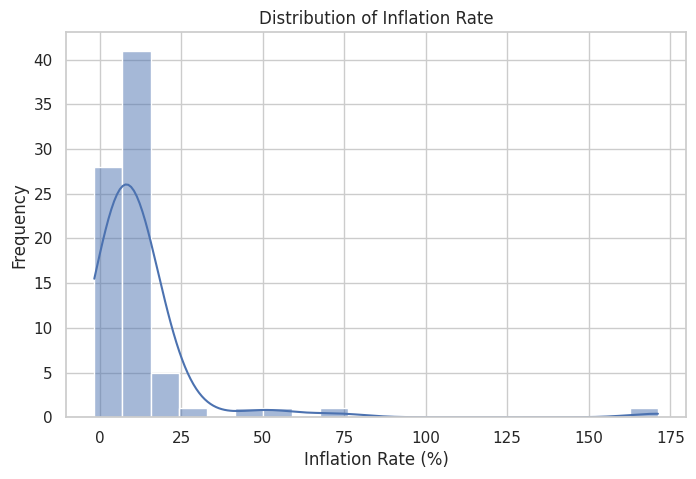

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(merged["inflation_rate"], bins=20, kde=True)
plt.title("Distribution of Inflation Rate")
plt.xlabel("Inflation Rate (%)")
plt.ylabel("Frequency")
plt.show()

The distribution of inflation rates appears to be right-skewed, with some countries experiencing much higher inflation than the majority.

## 4. Distribution of Obesity Rate

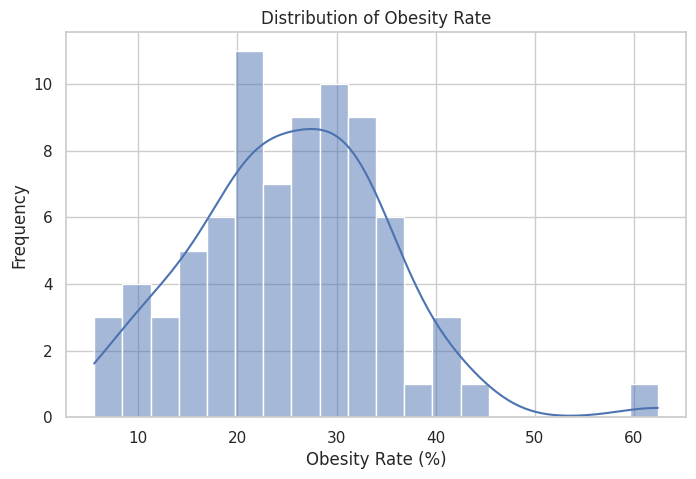

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(merged["obesity_rate"], bins=20, kde=True)
plt.title("Distribution of Obesity Rate")
plt.xlabel("Obesity Rate (%)")
plt.ylabel("Frequency")
plt.show()

Obesity rates are spread across countries, with most observations concentrated in a moderate range.

## 5. Distribution of Fast Food Density

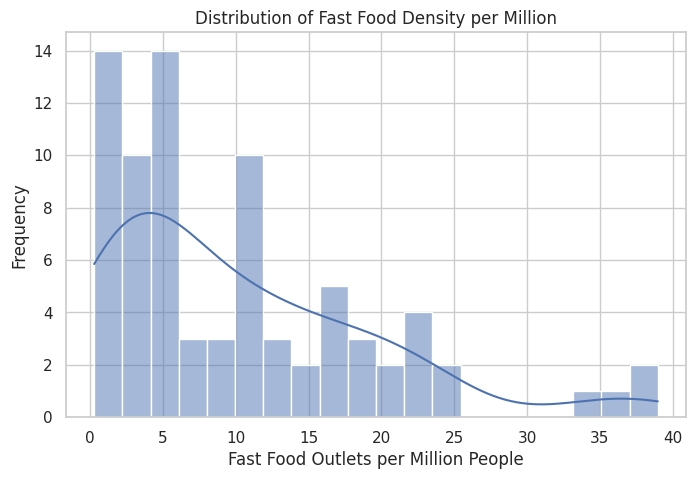

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(merged["fast_food_per_million"], bins=20, kde=True)
plt.title("Distribution of Fast Food Density per Million")
plt.xlabel("Fast Food Outlets per Million People")
plt.ylabel("Frequency")
plt.show()

Fast food density varies considerably across countries, suggesting unequal access to major fast food chains.

## 6. Inflation Rate vs Obesity Rate

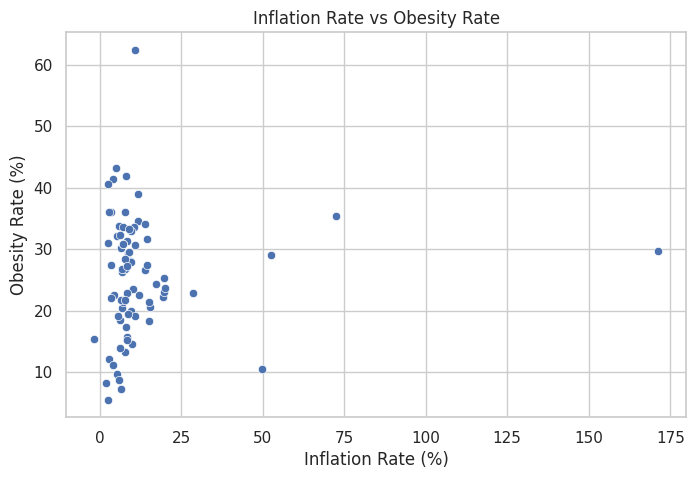

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=merged, x="inflation_rate", y="obesity_rate")
plt.title("Inflation Rate vs Obesity Rate")
plt.xlabel("Inflation Rate (%)")
plt.ylabel("Obesity Rate (%)")
plt.show()

The scatter plot does not show a very strong linear relationship between inflation and obesity. Any relationship appears weak and dispersed.

The scatter plot between inflation and obesity does not show a clear linear trend. The data points are widely dispersed, indicating that inflation does not strongly explain differences in obesity rates across countries.

Some outliers with extremely high inflation are present, but they do not form a consistent pattern. Overall, the relationship appears weak.

## 7. Fast Food Density vs Obesity Rate

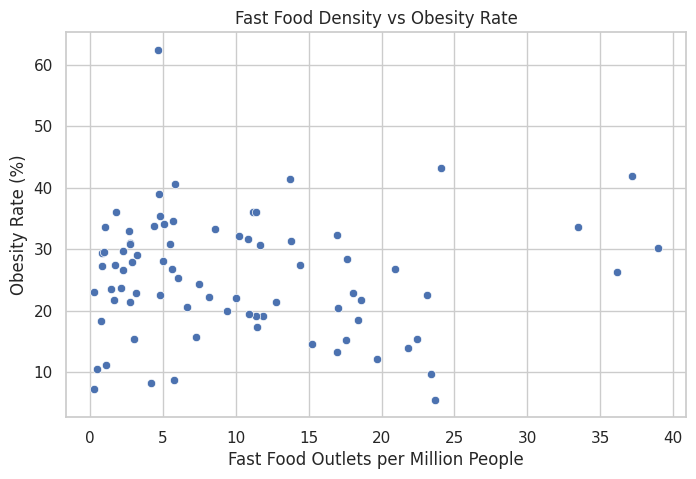

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=merged, x="fast_food_per_million", y="obesity_rate")
plt.title("Fast Food Density vs Obesity Rate")
plt.xlabel("Fast Food Outlets per Million People")
plt.ylabel("Obesity Rate (%)")
plt.show()

A more visible positive tendency may be observed here, suggesting that higher fast food availability could be associated with higher obesity rates.

The relationship between fast food density and obesity does not show a strong linear pattern. Although it might be expected that higher fast food availability leads to higher obesity rates, the data does not clearly support this assumption.

The points are scattered without a clear upward trend, suggesting that other factors beyond fast food availability may play a more important role in determining obesity levels.

## 8. Inflation Rate vs Fast Food Density

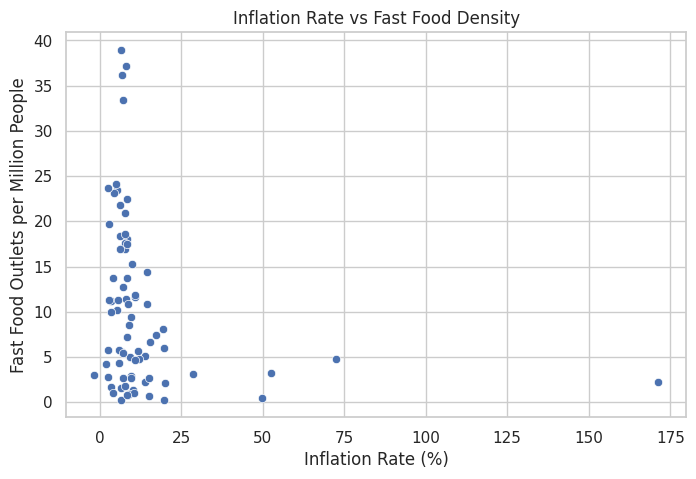

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=merged, x="inflation_rate", y="fast_food_per_million")
plt.title("Inflation Rate vs Fast Food Density")
plt.xlabel("Inflation Rate (%)")
plt.ylabel("Fast Food Outlets per Million People")
plt.show()

The relationship between inflation and fast food density does not appear strongly linear.

## 9. Correlation Matrix

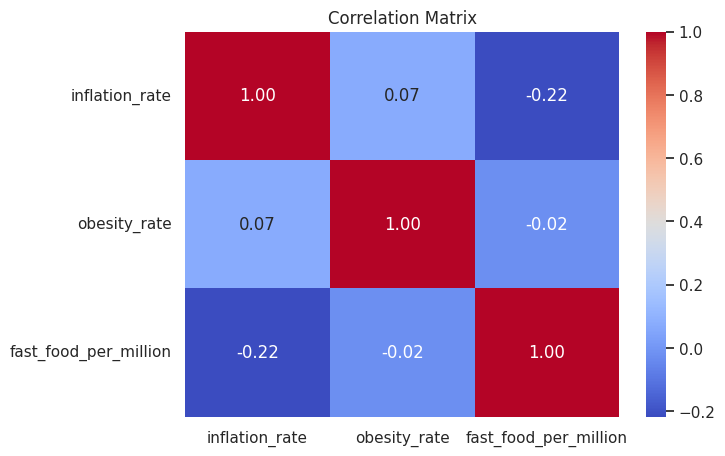

,inflation_rate,obesity_rate,fast_food_per_million
inflation_rate,1.000000,0.070050,-0.217196
obesity_rate,0.070050,1.000000,-0.022827
fast_food_per_million,-0.217196,-0.022827,1.000000


In [15]:
corr = merged[[
    "inflation_rate",
    "obesity_rate",
    "fast_food_per_million"
]].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

corr

The correlation matrix summarizes the linear relationships between the main variables. These values provide an initial numerical indication of association, but they should not be interpreted as causal effects.

The correlation matrix shows that the relationship between inflation and obesity is very weak (0.07), suggesting almost no linear association. Similarly, fast food density and obesity also exhibit a near-zero correlation (-0.02), indicating no clear linear relationship.

Interestingly, inflation and fast food density show a moderate negative correlation (-0.22), which may suggest that countries with higher inflation tend to have lower fast food density. However, all observed relationships are weak and should not be interpreted as causal.

## 10. Boxplots for Outlier Detection

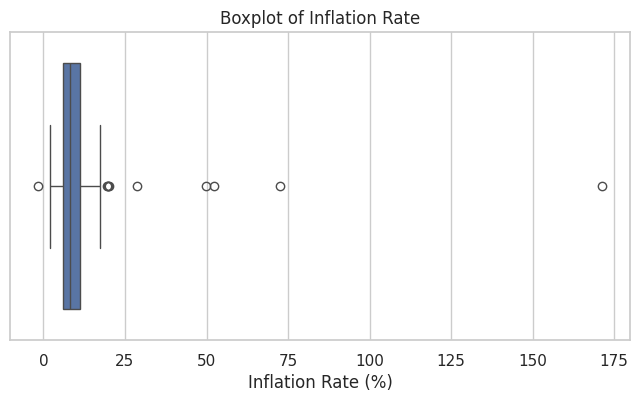

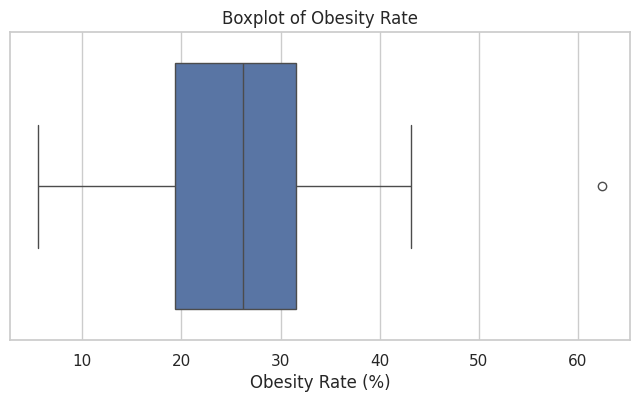

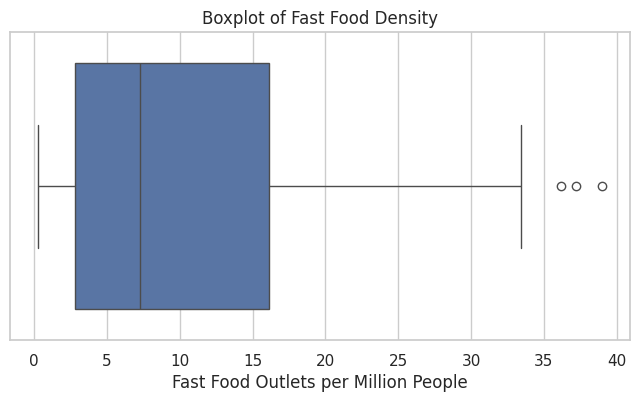

In [16]:
plt.figure(figsize=(8,4))
sns.boxplot(x=merged["inflation_rate"])
plt.title("Boxplot of Inflation Rate")
plt.xlabel("Inflation Rate (%)")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=merged["obesity_rate"])
plt.title("Boxplot of Obesity Rate")
plt.xlabel("Obesity Rate (%)")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=merged["fast_food_per_million"])
plt.title("Boxplot of Fast Food Density")
plt.xlabel("Fast Food Outlets per Million People")
plt.show()

The boxplots help identify extreme observations. Inflation is expected to contain stronger outliers than obesity because some countries can experience exceptionally high inflation.

## 11. Preliminary Findings

The exploratory analysis suggests that:

- inflation rates are highly variable and right-skewed,
- obesity rates are more moderately distributed,
- fast food density varies substantially across countries,
- the visual relationship between inflation and obesity appears weak,
- the relationship between fast food density and obesity appears more noticeable.

These findings are exploratory and motivate the next stage of the project, which is formal hypothesis testing.

## 12. Interpretation Note

At this stage, the analysis is descriptive and exploratory. Even if variables appear related in visualizations or correlations, this does not imply causation. Formal hypothesis tests are needed to evaluate whether the observed relationships are statistically significant.

These findings highlight that simple bivariate relationships may not fully capture the complexity of obesity determinants. Factors such as income level, lifestyle, healthcare systems, and cultural differences may also play a significant role.

Therefore, more advanced statistical methods such as hypothesis testing and regression analysis are required to better understand these relationships.